# Feature Engineering
Une `transactions`, `members_v3` y `user_logs` en una sola matriz de features por usuario.  
Salida: `data/processed/features_train.parquet`

| Fuente | Features | Cobertura |
|---|---|---|
| transactions | 14 | 100% |
| members_v3 | 6 | ~88% |
| user_logs | 7 | ~88% |

> La primera ejecución agrega user_logs (~10 min). Las siguientes usan el caché en `data/processed/user_logs_agg.parquet`.

In [1]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.append(str(ROOT))

from src.features.build_features_05 import (
    build_and_save,
    get_transaction_features,
    build_member_features,
    get_log_features,
    join_all,
    impute_missing,
    DATA_RAW,
    FEATURES_OUT,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Construir y guardar feature matrix

In [2]:
df = build_and_save()

── Cargando etiquetas de train ──
  992,931 usuarios | churn rate: 6.39%

── Features de transacciones ──
Cargando transacciones...
  22,978,755 filas | construyendo features por usuario...
  2,426,143 usuarios, 15 features

── Features de members ──
  6,769,473 usuarios, 6 features

── Features de user_logs ──
Cargando caché de user_logs (user_logs_agg.parquet)...
  5,234,111 usuarios, 15 features

── Uniendo tablas ──
  Shape antes de imputar: (992931, 32)
  Nulos por columna (top 10):
age                    603797
listening_trend        123005
days_since_last        123005
completion_ratio       123005
avg_daily_unq          123005
avg_daily_completed    123005
avg_daily_secs         123005
n_days                 123005
city                   115770
tenure_days            115770

── Imputando valores faltantes ──
  Nulos restantes: 0

── Guardando en /Users/josefrodriguez/repos_publicar/Churn_project/data/processed/features_train.parquet ──

✓ Feature matrix lista: 992,931 filas × 3

## 2. Inspección del dataset final

In [3]:
print(f'Shape: {df.shape}')
print(f'Churn rate: {df["is_churn"].mean():.2%}')
df.head()

Shape: (992931, 32)
Churn rate: 6.39%


,msno,is_churn,n_transactions,n_cancels,ever_canceled,avg_discount_pct,avg_plan_days,avg_price,n_unique_plans,n_payment_methods,...,tenure_days,n_days,avg_daily_secs,avg_daily_completed,avg_daily_unq,completion_ratio,days_since_last,listening_trend,has_member_record,has_log_record
0,waLDQMmcOu2jLDaV1ddDkgCrB/jl6sD66Xzs0Vqax1Y=,1,2,0,0,0.0,18.500000,74.500000,2,1,...,4346.0,26.0,4155.840538,15.730769,17.769231,0.808300,20.0,-1527.066205,1,1
1,QA7uiXy8vIbUSPOkCf9RwQ3FsT8jVq2OxDr8zqa7bRQ=,1,23,2,1,0.0,28.826087,150.347826,3,2,...,4345.0,521.0,5019.792971,19.082534,13.880998,0.916736,13.0,-4222.876971,1,1
2,fGwBva6hikQmTJzrbz/2Ezjm5Cth5jZUNvXigKK2AFA=,1,10,1,1,0.0,30.000000,149.200000,1,2,...,4153.0,237.0,10959.428928,42.333333,48.662447,0.752437,28.0,-10508.242928,1,1
3,mT5V8rEpa+8wuqi6x0DoVd3H5icMKkE9Prt49UlmK+4=,1,3,0,0,0.0,283.333333,645.666667,2,3,...,4136.0,735.0,6728.311370,24.585034,25.141497,0.579575,7.0,-1923.215325,1,1
4,XaPhtGLk/5UvvOYHcONTwsnH97P4eGECeq+BARGItRw=,1,9,0,0,0.0,97.222222,450.333333,4,1,...,4080.0,758.0,24596.500005,90.674142,95.875989,0.919552,0.0,-13674.390565,1,1


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_churn,992931.0,0.063923,0.244616,0.000000,0.000000,0.000000,0.000000,1.000000
n_transactions,992931.0,17.138657,8.450392,1.000000,10.000000,18.000000,24.000000,244.000000
n_cancels,992931.0,0.309130,0.608163,0.000000,0.000000,0.000000,0.000000,21.000000
ever_canceled,992931.0,0.248087,0.431903,0.000000,0.000000,0.000000,0.000000,1.000000
avg_discount_pct,992931.0,0.007371,0.036285,-0.007937,0.000000,0.000000,0.000000,1.000000
avg_plan_days,992931.0,33.643636,31.090772,1.000000,28.928571,30.000000,30.000000,450.000000
avg_price,992931.0,147.461340,133.040655,0.000000,99.000000,140.428571,149.000000,2000.000000
n_unique_plans,992931.0,1.556057,0.756727,1.000000,1.000000,1.000000,2.000000,8.000000
n_payment_methods,992931.0,1.191009,0.505921,1.000000,1.000000,1.000000,1.000000,8.000000
last_is_cancel,992931.0,0.045583,0.208580,0.000000,0.000000,0.000000,0.000000,1.000000


In [5]:
# Nulos restantes
nulls = df.isnull().sum()
print('Nulos por columna:')
print(nulls[nulls > 0] if nulls.any() else 'Ninguno ✓')

Nulos por columna:
Ninguno ✓


## 3. Cobertura de las distintas fuentes

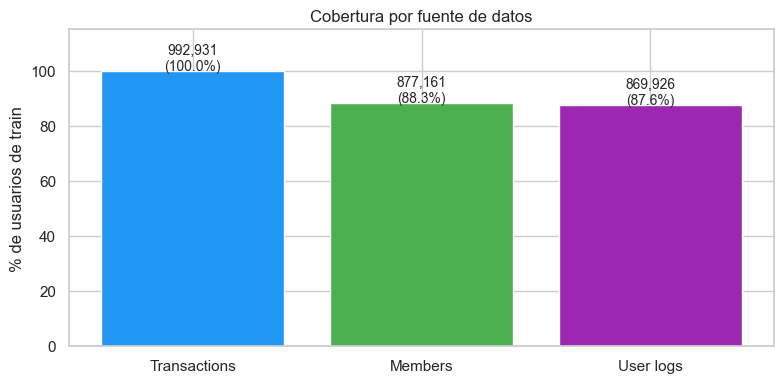

In [6]:
labels = pd.read_csv(DATA_RAW / 'train.csv')[['msno', 'is_churn']]
total = len(labels)

coverage = {
    'Transactions': df['n_transactions'].notna().sum(),
    'Members': df['has_member_record'].sum(),
    'User logs': df['has_log_record'].sum(),
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(coverage.keys(), [v / total * 100 for v in coverage.values()],
              color=['#2196F3', '#4CAF50', '#9C27B0'], edgecolor='white')
for bar, (k, v) in zip(bars, coverage.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:,}\n({v/total:.1%})', ha='center', fontsize=10)
ax.set_ylim(0, 115)
ax.set_ylabel('% de usuarios de train')
ax.set_title('Cobertura por fuente de datos')
plt.tight_layout()
plt.show()

## 4. Distribuciones de features clave

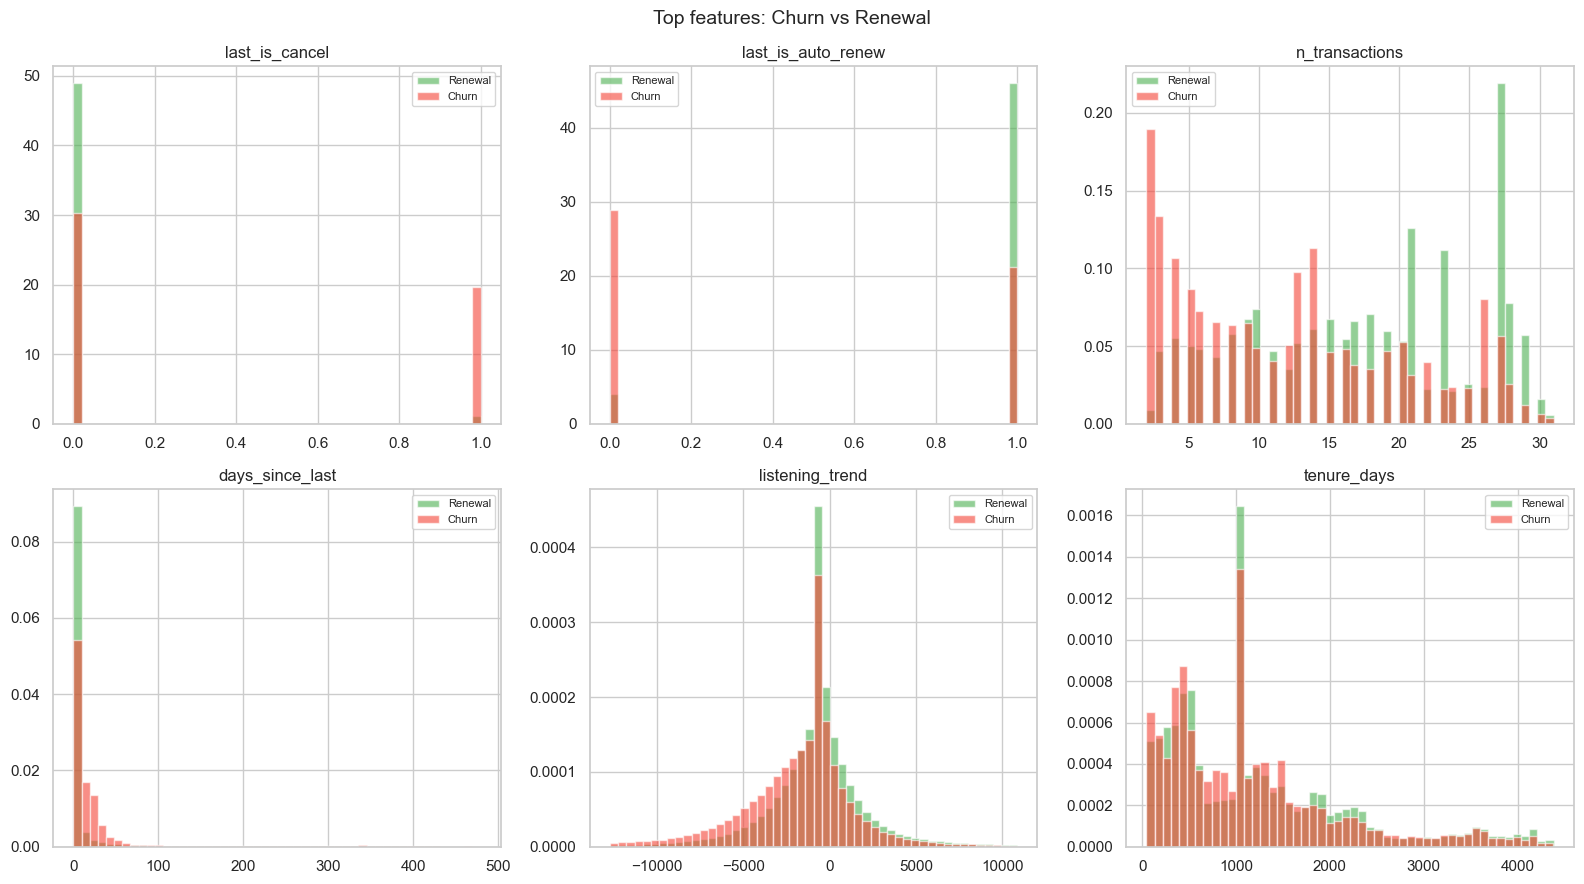

In [7]:
KEY_FEATURES = [
    'last_is_cancel', 'last_is_auto_renew', 'n_transactions',
    'days_since_last', 'listening_trend', 'tenure_days',
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, KEY_FEATURES):
    lo, hi = df[col].quantile([0.01, 0.99])
    data = df[df[col].between(lo, hi)]
    renewal = data[data['is_churn'] == 0][col]
    churn = data[data['is_churn'] == 1][col]
    ax.hist(renewal, bins=50, alpha=0.6, color='#4CAF50', label='Renewal', density=True)
    ax.hist(churn, bins=50, alpha=0.6, color='#F44336', label='Churn', density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Top features: Churn vs Renewal', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Correlación con el target

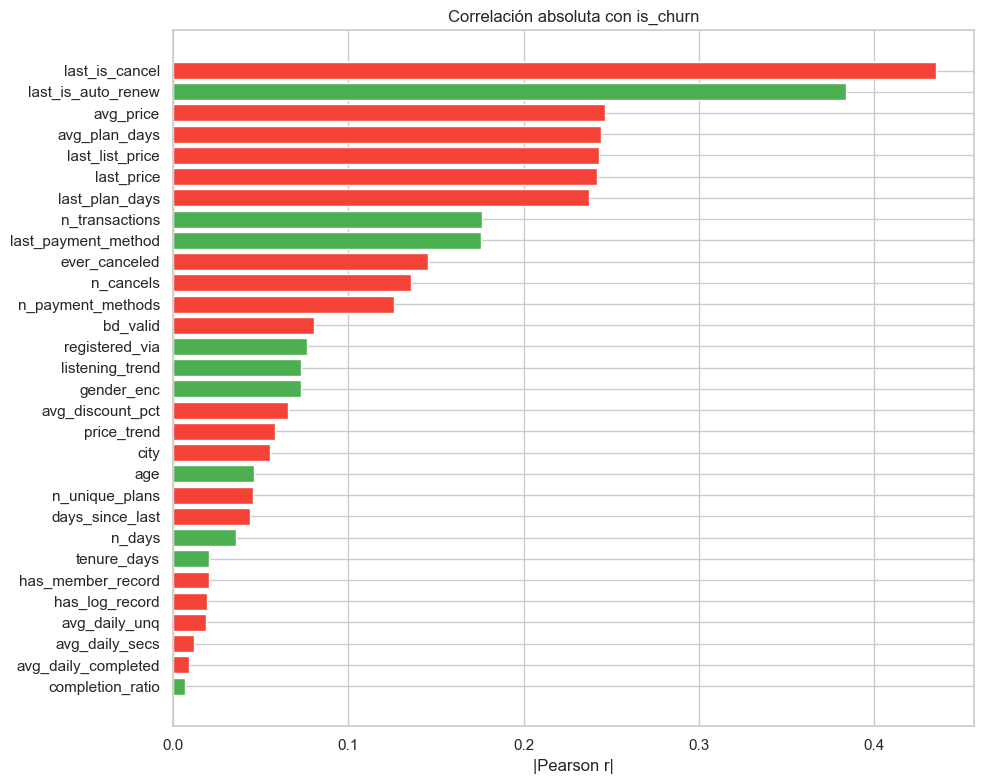


Top 10 features por correlación con is_churn:
last_is_cancel         0.435103
last_is_auto_renew    -0.383921
avg_price              0.246064
avg_plan_days          0.244124
last_list_price        0.242888
last_price             0.241511
last_plan_days         0.237342
n_transactions        -0.176096
last_payment_method   -0.175442
ever_canceled          0.145531


In [8]:
feature_cols = [c for c in df.columns if c not in ['msno', 'is_churn']]
corr = df[feature_cols + ['is_churn']].corr()['is_churn'].drop('is_churn')
corr_sorted = corr.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#F44336' if corr[f] > 0 else '#4CAF50' for f in corr_sorted.index]
ax.barh(corr_sorted.index[::-1], corr_sorted.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_title('Correlación absoluta con is_churn')
ax.set_xlabel('|Pearson r|')
plt.tight_layout()
plt.show()

print('\nTop 10 features por correlación con is_churn:')
print(corr.reindex(corr_sorted.index).head(10).to_string())

## 6. Matriz de correlación entre features

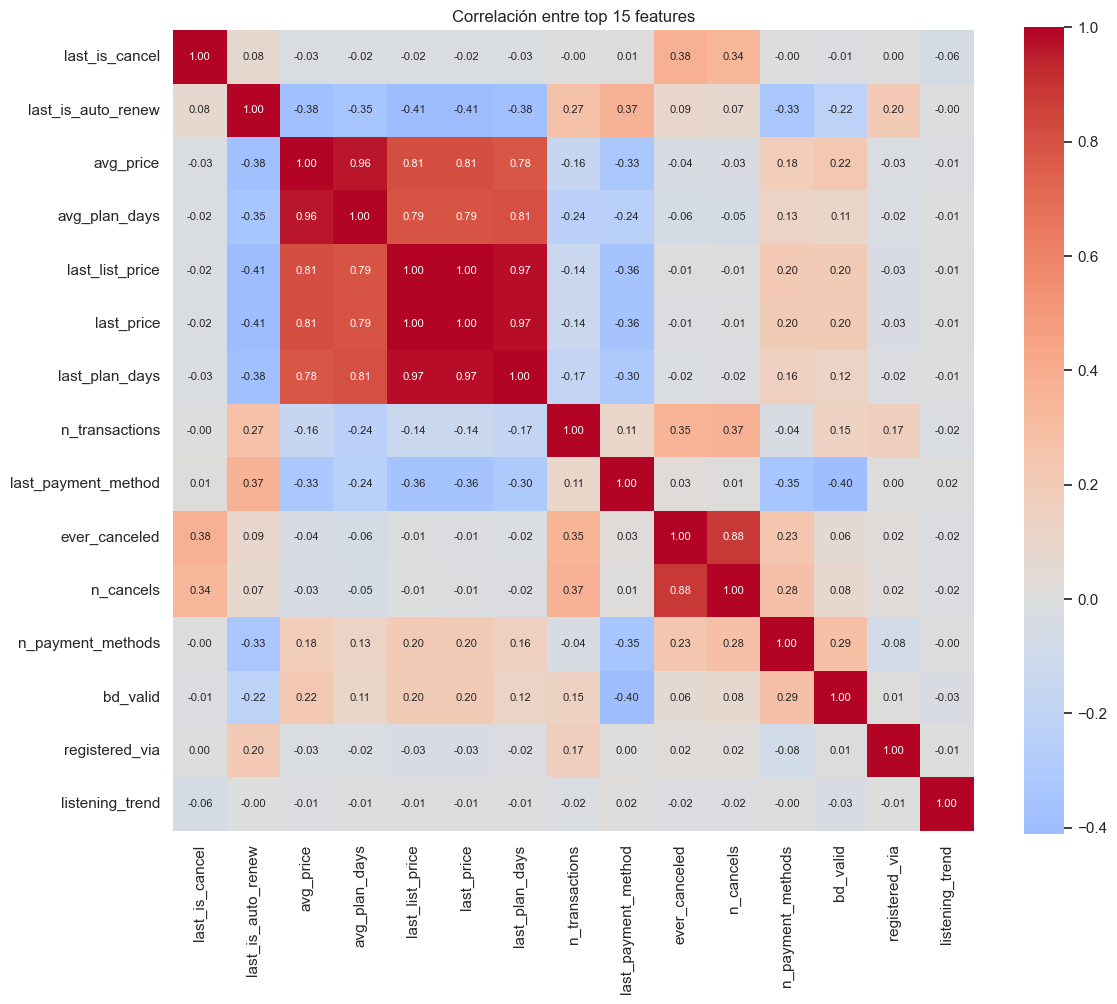

In [9]:
top_features = corr_sorted.head(15).index.tolist()
corr_matrix = df[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlación entre top 15 features')
plt.tight_layout()
plt.show()

## 7. Resumen del dataset

El parquet está en `data/processed/features_train.parquet` y es el input directo para el modelado.

In [10]:
print('═' * 60)
print('FEATURE MATRIX — RESUMEN')
print('═' * 60)
print(f'  Usuarios         : {len(df):,}')
print(f'  Features         : {len(feature_cols)}')
print(f'  Churn rate       : {df["is_churn"].mean():.2%}')
print(f'  Con registro members: {df["has_member_record"].mean():.1%}')
print(f'  Con registro logs   : {df["has_log_record"].mean():.1%}')
print(f'  Nulos restantes  : {df.isnull().sum().sum()}')
print(f'  Guardado en      : data/processed/features_train.parquet')

════════════════════════════════════════════════════════════
FEATURE MATRIX — RESUMEN
════════════════════════════════════════════════════════════
  Usuarios         : 992,931
  Features         : 30
  Churn rate       : 6.39%
  Con registro members: 88.3%
  Con registro logs   : 87.6%
  Nulos restantes  : 0
  Guardado en      : data/processed/features_train.parquet
